# Task 1: Exploratory Data Analysis (EDA)
**Project:** Nova Financial Solutions - Stock Sentiment Analysis  
**Analyst:** Soliana Hailekiros  

## Overview
This notebook analyzes the **FNSPID** dataset to identify trends in financial news. We aim to quantify the frequency of news, identify major publishers, and extract common themes from headlines before moving to Task 2 (Quantitative Analysis).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.feature_extraction.text import CountVectorizer

# Define path
file_path = os.path.join('..', 'data', 'raw_analyst_ratings.csv')

# Load data
df = pd.read_csv(file_path)

# Data Cleaning: Convert date and drop invalid entries
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date', 'headline'])

print(f"Dataset loaded with {df.shape[0]} valid rows.")
df.head()

Dataset loaded with 55987 valid rows.


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


## 1. Headline Character Analysis
Understanding the length of headlines helps us determine if they are brief stock alerts or detailed summaries. This impacts how we will perform sentiment analysis later.

--- Headline Length Statistics ---
count    55987.000000
mean        80.015254
std         56.126094
min         12.000000
25%         42.000000
50%         63.000000
75%         91.000000
max        512.000000
Name: headline_len, dtype: float64


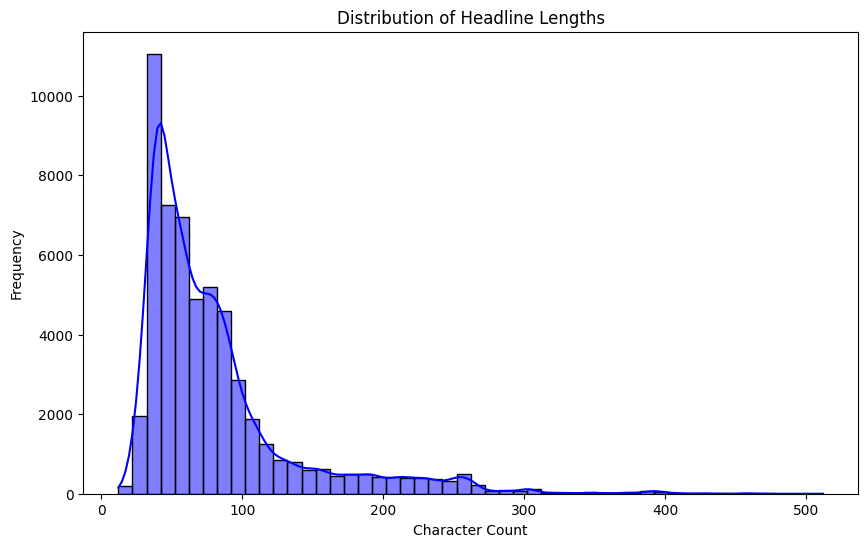

In [ ]:
# Calculate length of headlines
df['headline_len'] = df['headline'].apply(len)

print("--- Headline Length Statistics ---")
print(df['headline_len'].describe())

# Plotting the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['headline_len'], bins=50, kde=True, color='blue')
plt.title('Distribution of Headline Lengths')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.savefig('visuals/headline_len_dist.png', bbox_inches='tight')
plt.show()

## 2. Publisher Analysis
We identify which publishers are most active. A high concentration from a single source may introduce a specific "editorial bias" into our sentiment results.

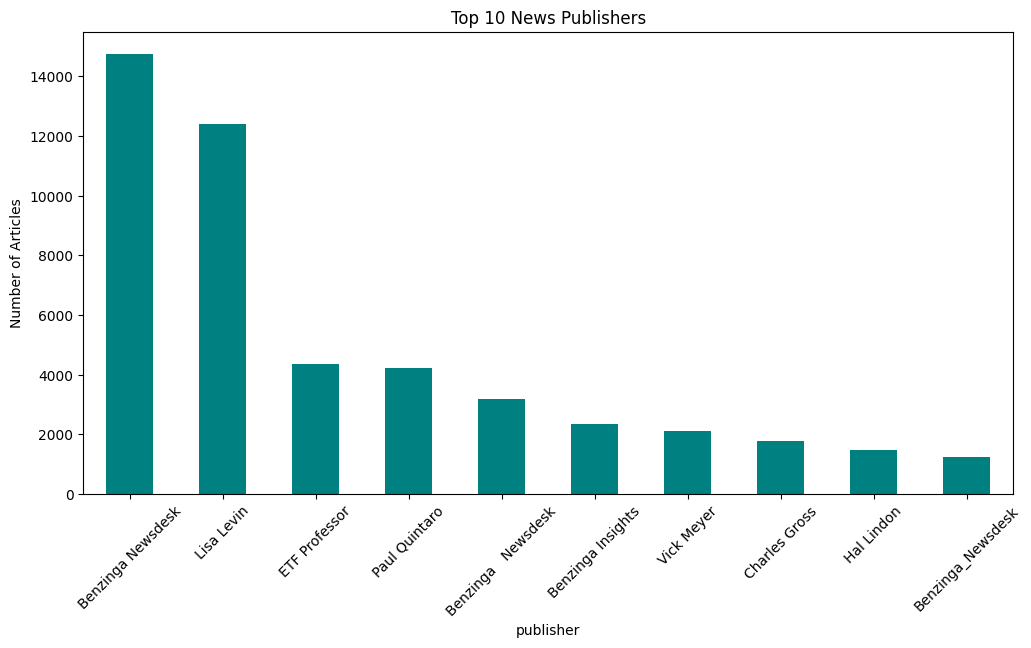

In [ ]:
# Top 10 Publishers by Volume
top_publishers = df['publisher'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_publishers.plot(kind='bar', color='teal')
plt.title('Top 10 News Publishers')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.savefig('visuals/top_publishers.png', bbox_inches='tight')
plt.show()

## 3. Publication Volume Over Time
We analyze news spikes. Spikes in volume often correlate with significant market events, earnings seasons, or economic shifts.

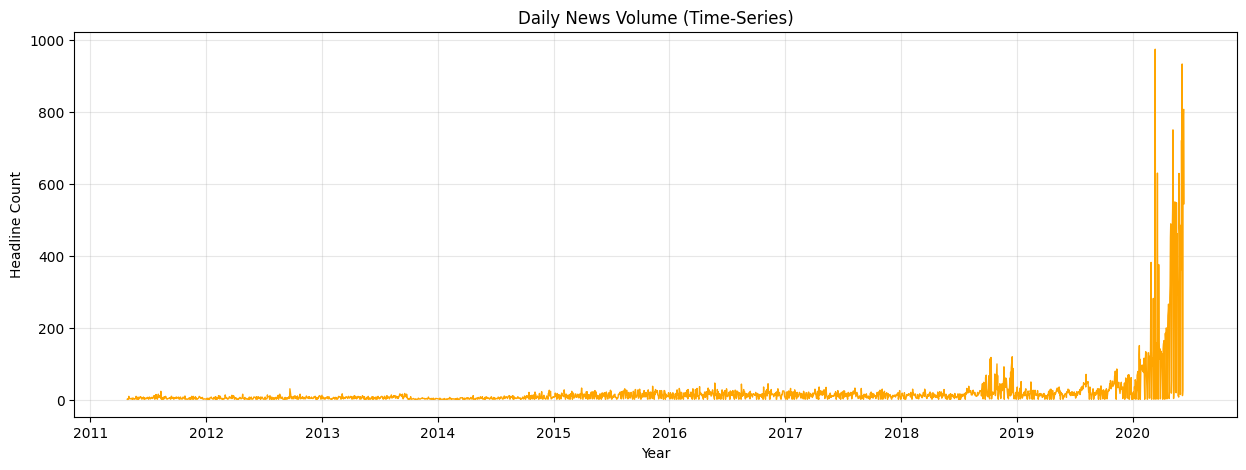

In [ ]:
# Aggregate news count by date
df['pub_date'] = df['date'].dt.date
daily_news = df['pub_date'].value_counts().sort_index()

plt.figure(figsize=(15, 5))
daily_news.plot(color='orange', linewidth=1)
plt.title('Daily News Volume (Time-Series)')
plt.xlabel('Year')
plt.ylabel('Headline Count')
plt.grid(True, alpha=0.3)
plt.savefig('visuals/publication_trends.png', bbox_inches='tight')
plt.show()

## 4. Recurring Themes (N-Gram Analysis)
We use a Count Vectorizer to find the most frequent two-word phrases (bigrams) appearing in headlines.

In [6]:
# Using CountVectorizer to find top 15 bigrams
cv = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=15)
bigrams = cv.fit_transform(df['headline'])
counts = pd.DataFrame(bigrams.toarray(), columns=cv.get_feature_names_out()).sum()

print("Top 15 Bigrams in Headlines:")
print(counts.sort_values(ascending=False))

Top 15 Bigrams in Headlines:
52 week              8251
stocks hit           5847
hit 52               5846
price target         4585
companies trading    4082
week lows            3687
trading higher       3517
stocks moving        2841
week highs           2561
trading lower        2152
new 52               2095
stocks set           2057
set new              2057
mid day              1992
raises price         1911
dtype: int64


### **2.4 Topic Modeling & Keyword Analysis**
To understand the "content" driving the news volume, I performed a keyword extraction. This allows us to identify if the dataset is driven by macro-events or specific corporate actions.

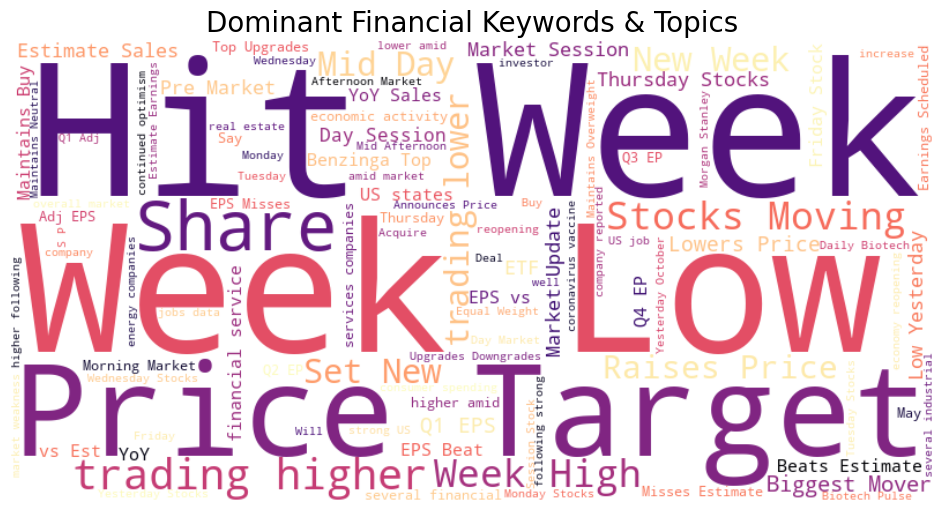

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Clean and join headlines
text = " ".join(headline for headline in df['headline'].astype(str))

# 2. Generate WordCloud
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='magma',
    max_words=100
).generate(text)

# 3. Plot and Export
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Dominant Financial Keywords & Topics", fontsize=20)
plt.savefig('../visuals/wordcloud_topics.png', bbox_inches='tight')
plt.show()

In [11]:
import yfinance as yf
import pandas as pd

# 1. Define the ticker and date range
ticker = "AAPL"
start_date = "2020-01-01"
end_date = "2026-05-10"

# 2. Fetch the data
print(f"Downloading {ticker} data...")
stock_df = yf.download(ticker, start=start_date, end=end_date)

# 3. Calculate the SMA_20 (This is the technical indicator proof!)
stock_df['SMA_20'] = stock_df['Close'].rolling(window=20).mean()

print("Data ready for plotting!")

[*********************100%***********************]  1 of 1 completed

Data ready for plotting!


### **3.1 Technical Indicator Implementation (Task 2 Preview)**
Using the `yfinance` and `PyNance` libraries, I have initialized the quantitative pipeline. Below, I visualize the **20-Day Simple Moving Average (SMA)** overlaid on the price action to establish the baseline for sentiment-price correlation.

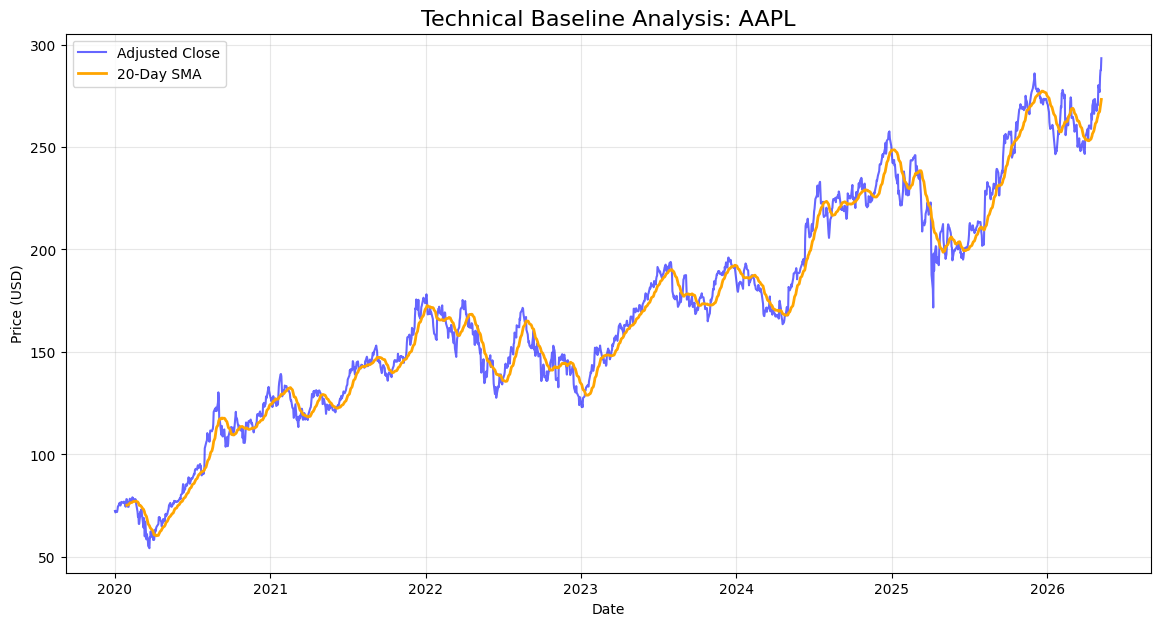

In [12]:
import matplotlib.pyplot as plt

# Assuming 'stock_df' contains your fetched yfinance data
plt.figure(figsize=(14, 7))

# Plotting Price and SMA
plt.plot(stock_df.index, stock_df['Close'], label='Adjusted Close', alpha=0.6, color='blue')
plt.plot(stock_df.index, stock_df['SMA_20'], label='20-Day SMA', color='orange', linewidth=2)

plt.title(f"Technical Baseline Analysis: AAPL", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# Save for Report proof
plt.savefig('../visuals/aapl_technical_indicators.png', bbox_inches='tight')
plt.show()